<a href="https://colab.research.google.com/github/behraj/journals/blob/main/FADE_reviewer_experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FADE — Reviewer-Requested Experiments (P2, P3, P11)

This notebook implements the three experiments flagged as **"Accept — escalate scope"** in the FADE reviewer-triage plan, i.e. the ones that need new runs rather than a text fix:

- **P2** (R1#4 + R2#5): direct evaluation of the shift *detector* itself — precision/recall/F1/FPR, detection delay, AUROC of $\tau_t$ against known shift points; comparison of the full Fisher–KL signal vs. KL-only vs. Fisher-only; sensitivity sweep over $\alpha,\lambda,\gamma$.
- **P3** (R1#5 + R2#7): federated client-permutation experiment (does final accuracy depend on client visiting order, since FADE is explicitly path-dependent per Section 2.1) and a detection-gate ablation (unconditional regularization every round vs. the gated $\tau_t>\gamma$ rule).
- **P11** (R2#6): a controlled experiment with a *verified* label-preserving transformation, so at least one benchmark demonstrably satisfies the paper's own formal SCS definition (Eq. 1: $P(X)$ shifts, $P(Y\mid X)$ fixed) rather than being audited after the fact.

## Important caveats before you run this

1. **This is a reference implementation from the paper's equations, not your codebase.** I do not have your actual FADE implementation, model architectures, or data pipeline. Section 1 below implements FADE from Eq. (1)–(7) and the *corrected* Algorithm 1 (per the method-section fixes: warm-up initialization, update-order fix, no layer-wise gate, statistics-only memory). If your implementation differs in any of these details, the qualitative experiment design here still applies, but you should port these functions into your own code before trusting the numbers for the paper.
2. **The KL-divergence estimator is an assumption I had to make.** Eq. (1)/(3) define $D_{KL}(P_t\|P_{t-1})$ over the raw input distribution $P(X)$, but the .tex never specifies *how* this is estimated in practice (raw pixels are too high-dimensional for a direct KDE/histogram estimate). I used a common practical proxy: embed each batch with the model's current penultimate-layer representation, fit a diagonal Gaussian to each batch's embeddings, and use the closed-form Gaussian KL. **If your actual implementation uses a different estimator (kernel density, k-NN, MMD, a fixed feature extractor, etc.), replace `batch_kl_gaussian` below** — everything downstream (the detection metrics, the sweeps) is estimator-agnostic and will work with any $\tau_t$ trajectory.
3. **The Fisher estimator's label source is the Fix 2 decision you haven't made yet.** `diagonal_empirical_fisher` below takes a `label_source` argument (`'true'` or `'predicted'`) — set it to match whichever way you resolve the abstract's "no target labels" claim vs. Eq. (6)'s supervised loss.
4. **Per-example Fisher computation is a plain Python loop** (`for i in range(n): ...`) for clarity/correctness, not speed. It will be slow on large batches/models. For real experiments, vectorize with `torch.func.vmap` + `torch.func.grad`, or compute the Fisher on a random subsample of each batch (state which, if you do, in the paper).
5. **The $\gamma$-sweep in P2 has a feedback-loop caveat, stated again at that cell.** Because adaptation changes the model, which changes future embeddings/Fisher/KL, $\tau_t$ is not strictly independent of the $\gamma$ used at runtime. I run one pass at a reasonable operating $\gamma$ and sweep thresholds post-hoc on the resulting trajectory for the precision/recall curve — this is standard practice for this kind of detector evaluation but is worth stating explicitly in the paper's methodology.

Install requirements if needed: `pip install torch torchvision scikit-learn pandas matplotlib`


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd
import itertools

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("device:", device)


device: cuda


## 1. FADE core implementation

Implements Eq. (2)/Fix-1 (discriminative diagonal empirical Fisher), the KL proxy discussed above, $\tau_t$ (Eq. 3), the Cramér–Rao regularizer (Eq. 6), and the **corrected** Algorithm 1: explicit $I_0,P_0$ warm-up initialization (Fix 6a), optimization-before-smoothing-update ordering so the loss uses $I_{\mathrm{global}}^{(t-1)}$ as Eq. (6) specifies (Fix 6b), no layer-wise gate (Fix 6c — removed from the method write-up, so removed here too), and only diagonal-FIM statistics retained between batches, not raw data (Fix 6d).

`FADEState.step(...)` exposes two arguments the experiments below need:
- `signal`: which of `{'full','kl','fisher'}` gates adaptation — needed for **P2**'s comparison of the full signal against its two ablated components (mirrors `tab:ablation`'s existing rows, but for *detection*, not downstream accuracy).
- `force_update`: if `True`, applies the regularized update every batch unconditionally, ignoring $\gamma$ — this **is** the detection-gate ablation requested in **P3**.

In [ ]:
class SmallCNN(nn.Module):
    """Small CNN for MNIST-family inputs (1x28x28)."""
    def __init__(self, n_classes=10, embed_dim=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.embed = nn.Linear(32 * 7 * 7, embed_dim)
        self.head = nn.Linear(embed_dim, n_classes)

    def forward(self, x, return_embed=False):
        z = self.conv(x).flatten(1)
        e = F.relu(self.embed(z))
        logits = self.head(e)
        return (logits, e) if return_embed else logits


class SmallMLP(nn.Module):
    """Small MLP for the synthetic tabular sanity-check stream."""
    def __init__(self, in_dim, n_classes=2, embed_dim=32):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, 64)
        self.embed = nn.Linear(64, embed_dim)
        self.head = nn.Linear(embed_dim, n_classes)

    def forward(self, x, return_embed=False):
        h = F.relu(self.fc1(x))
        e = F.relu(self.embed(h))
        logits = self.head(e)
        return (logits, e) if return_embed else logits


In [ ]:
def diagonal_empirical_fisher(model, x, y=None, label_source='true'):
    """
    Diagonal empirical Fisher (Fix 1's corrected Eq. 2):
        diag( 1/n * sum_i grad_theta log p_theta(y_i|x_i) (x) grad_theta log p_theta(y_i|x_i) )

    label_source:
      'true'      -- use ground-truth labels (matches Eq. 6 as currently written; Fix 2 Option B)
      'predicted' -- use the model's own argmax prediction as a pseudo-label
                     (needed if you adopt Fix 2 Option A, the label-free variant)

    NOTE: plain per-example loop for correctness/clarity, not speed.
    """
    model.eval()
    params = [p for p in model.parameters() if p.requires_grad]
    fisher_diag = [torch.zeros_like(p) for p in params]
    n = x.size(0)
    for i in range(n):
        model.zero_grad(set_to_none=True)
        xi = x[i:i + 1]
        logits = model(xi)
        logp = F.log_softmax(logits, dim=-1)
        if label_source == 'true':
            yi = y[i:i + 1]
        else:
            yi = logits.argmax(dim=-1).detach()
        loss = F.nll_loss(logp, yi)
        grads = torch.autograd.grad(loss, params, retain_graph=False, allow_unused=True)
        for fd, g in zip(fisher_diag, grads):
            if g is not None:
                fd += g.detach() ** 2
    fisher_diag = [fd / n for fd in fisher_diag]
    return torch.cat([fd.flatten() for fd in fisher_diag])


def batch_kl_gaussian(model, x_prev, x_curr, eps=1e-4):
    """
    Practical proxy for D_KL(P_t || P_{t-1}) over P(X) (Eq. 1/3): embed both
    batches with the model's current penultimate representation, fit a
    diagonal Gaussian to each, use the closed-form Gaussian KL.
    ASSUMPTION -- not specified in the .tex; swap in your own estimator if
    your implementation differs (see the caveats cell above).
    """
    model.eval()
    with torch.no_grad():
        _, e_prev = model(x_prev, return_embed=True)
        _, e_curr = model(x_curr, return_embed=True)
    mu_p, var_p = e_prev.mean(0), e_prev.var(0) + eps
    mu_c, var_c = e_curr.mean(0), e_curr.var(0) + eps
    kl = 0.5 * torch.sum(var_c / var_p + (mu_p - mu_c) ** 2 / var_p - 1 + torch.log(var_p / var_c))
    return kl.item()


In [ ]:
class FADEState:
    """Corrected Algorithm 1 (Fix 6). Tracks I_prev, the smoothed I_global,
    mu_prev = theta_{t-1}, and the previous batch (statistics only, per Fix 6d
    -- x_prev_batch is kept here only to compute this step's KL and is
    overwritten immediately after, matching the paper's O(d) memory claim
    once the KL estimator's own memory cost is likewise bounded)."""

    def __init__(self, model, alpha=0.9, lam=1.0, gamma=1.0, label_source='true'):
        self.model = model
        self.alpha = alpha
        self.lam = lam
        self.gamma = gamma
        self.label_source = label_source
        self.I_prev = None
        self.I_global = None
        self.mu_prev = None
        self.x_prev_batch = None

    def flat_params(self):
        return torch.cat([p.detach().flatten() for p in self.model.parameters()])

    def init_warmup(self, x0, y0, eps_diag=1e-3):
        """Fix 6a: explicit I_0, P_0 (via x0), mu_0 initialization."""
        I0 = diagonal_empirical_fisher(self.model, x0, y0, self.label_source)
        self.I_prev = I0
        self.I_global = torch.full_like(I0, eps_diag)
        self.mu_prev = self.flat_params()
        self.x_prev_batch = x0

    def step(self, x_t, y_t, optimizer, n_inner_steps=1, force_update=False, signal='full'):
        """One FADE batch step.
        signal in {'full','kl','fisher'} selects which term gates adaptation
          (for the P2 detection-signal-variant comparison).
        force_update=True applies the regularized update unconditionally
          (the P3 detection-gate ablation).
        Returns (updated, tau_full, tau_kl_only, tau_fisher_only, triggered)."""
        I_t = diagonal_empirical_fisher(self.model, x_t, y_t, self.label_source)
        kl = batch_kl_gaussian(self.model, self.x_prev_batch, x_t)
        fro = torch.norm(I_t - self.I_prev, p=2).item()  # Frobenius norm of a diagonal matrix = L2 norm of its diagonal
        tau_full, tau_kl_only, tau_fisher_only = fro * kl, kl, fro
        signal_val = {'full': tau_full, 'kl': tau_kl_only, 'fisher': tau_fisher_only}[signal]

        triggered = force_update or (signal_val > self.gamma)
        updated = False
        if triggered:
            I_global_prev = self.I_global.clone()  # Fix 6b: use I_global^{(t-1)} in the loss, as Eq. (6) specifies
            params = list(self.model.parameters())
            for _ in range(n_inner_steps):
                optimizer.zero_grad(set_to_none=True)
                logits = self.model(x_t)
                ce = F.cross_entropy(logits, y_t)
                theta_flat = torch.cat([p.flatten() for p in params])
                reg = torch.sum(I_global_prev * (theta_flat - self.mu_prev) ** 2)
                loss = ce + self.lam * reg
                loss.backward()
                optimizer.step()
            self.I_global = self.alpha * self.I_global + (1 - self.alpha) * I_t
            self.mu_prev = self.flat_params()
            updated = True
        # else: theta_t <- theta_{t-1} (no-op; optimizer not stepped)

        self.I_prev = I_t
        self.x_prev_batch = x_t
        return updated, tau_full, tau_kl_only, tau_fisher_only, triggered


## 2. Data streams

Two streams:

- **Synthetic Gaussian-shift stream** — fully controllable ground truth, used to sanity-check the detector plumbing (P2) before touching real data.
- **Rotated-MNIST covariate-shift stream** — the P11 controlled experiment. Rotation is applied uniformly to a batch and is nominally label-preserving; we do **not** assume this holds, we verify it with a frozen reference classifier below.

In [ ]:
def make_synthetic_stream(n_batches=30, batch_size=64, dim=20,
                           shift_batches=(10, 20), shift_magnitude=3.0, seed=0):
    """2-class Gaussian stream. P(X)'s mean shifts by `shift_magnitude` at
    each index in `shift_batches`; the separating hyperplane w is fixed for
    every batch, so P(Y|X) is exactly preserved -- this is a bona fide SCS
    stream (Eq. 1) by construction, used only to validate the detector code."""
    rng = np.random.RandomState(seed)
    mean_shift = np.zeros(dim)
    w = rng.randn(dim); w /= np.linalg.norm(w)
    xs, ys, gt = [], [], []
    for t in range(n_batches):
        if t in shift_batches:
            direction = rng.randn(dim); direction /= np.linalg.norm(direction)
            mean_shift = mean_shift + shift_magnitude * direction
        x = rng.randn(batch_size, dim) + mean_shift
        logits = x @ w
        y = (logits > np.median(logits)).astype(np.int64)  # same w every batch -> P(Y|X) fixed
        xs.append(torch.tensor(x, dtype=torch.float32))
        ys.append(torch.tensor(y, dtype=torch.long))
        gt.append(1 if t in shift_batches else 0)
    return xs, ys, gt


def load_mnist(root='./data', train=True):
    tfm = T.Compose([T.ToTensor()])
    return torchvision.datasets.MNIST(root=root, train=train, download=True, transform=tfm)


def make_rotated_mnist_stream(mnist_ds, n_batches=20, batch_size=128,
                               shift_batches=(7, 14), max_angle=35, seed=0):
    """Pure covariate-shift stream for P11: i.i.d. MNIST subsamples rotated
    by an angle that steps up at `shift_batches`. Digit identity (label) is
    unchanged by rotation -- verified explicitly below, not assumed."""
    rng = np.random.RandomState(seed)
    idx_pool = rng.permutation(len(mnist_ds))
    angle, ptr = 0.0, 0
    xs, ys, gt, angles = [], [], [], []
    for t in range(n_batches):
        if t in shift_batches:
            angle += max_angle
        idxs = idx_pool[ptr:ptr + batch_size]; ptr += batch_size
        imgs, labels = [], []
        for i in idxs:
            img, label = mnist_ds[int(i)]
            if angle != 0:
                img = T.functional.rotate(img, angle)
            imgs.append(img); labels.append(label)
        xs.append(torch.stack(imgs))
        ys.append(torch.tensor(labels, dtype=torch.long))
        gt.append(1 if t in shift_batches else 0)
        angles.append(angle)
    return xs, ys, gt, angles


def verify_label_preservation(reference_model, xs, ys, device):
    """P11 requirement: confirm P(Y|X) is preserved under rotation by
    checking a FROZEN reference classifier's agreement with the true labels
    on each (possibly rotated) batch. High, stable agreement across batches
    supports treating the stream as pure covariate shift, not a confound
    with label/concept shift. The reference model must be trained on CLEAN
    (unrotated) data only, and separately from the FADE model under test."""
    reference_model.eval()
    agreements = []
    with torch.no_grad():
        for x, y in zip(xs, ys):
            x, y = x.to(device), y.to(device)
            pred = reference_model(x).argmax(-1)
            agreements.append((pred == y).float().mean().item())
    return agreements


## 3. Detection evaluation metrics (P2)

Precision/recall/F1/FPR at a chosen $\gamma$, detection delay (batches between a true shift and the first trigger within a tolerance window), fraction of true shifts ever detected, and AUROC of $\tau_t$ as a continuous shift score against the binary ground truth.

In [ ]:
def evaluate_detection(tau_trajectory, ground_truth, gamma, tolerance_window=1):
    tau = np.array(tau_trajectory)
    gt = np.array(ground_truth)
    pred = (tau > gamma).astype(int)

    tp = int(((pred == 1) & (gt == 1)).sum())
    fp = int(((pred == 1) & (gt == 0)).sum())
    fn = int(((pred == 0) & (gt == 1)).sum())
    tn = int(((pred == 0) & (gt == 0)).sum())

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    delays = []
    for s in np.where(gt == 1)[0]:
        detected = None
        for t in range(s, min(len(pred), s + 1 + tolerance_window)):
            if pred[t] == 1:
                detected = t - s
                break
        delays.append(detected)

    try:
        auroc = roc_auc_score(gt, tau) if len(set(gt)) > 1 else float('nan')
    except ValueError:
        auroc = float('nan')

    finite_delays = [d for d in delays if d is not None]
    return dict(precision=precision, recall=recall, f1=f1, fpr=fpr,
                mean_delay=(np.mean(finite_delays) if finite_delays else None),
                detected_fraction=(np.mean([d is not None for d in delays]) if delays else float('nan')),
                auroc=auroc, tp=tp, fp=fp, fn=fn, tn=tn)


In [ ]:
def run_stream_collect_tau(model_ctor, xs, ys, alpha=0.9, lam=1.0, gamma=1.0,
                           lr=1e-3, warmup_frac=0.1, label_source='true',
                           signal='full', force_update=False, device='cpu'):
    """Runs one full FADE pass over a stream, gating adaptation on `signal`
    (full/kl/fisher) -- this is what makes the three P2 signal-variant runs
    genuinely different systems (with feedback), not just three post-hoc
    re-thresholdings of the same trajectory."""
    model = model_ctor().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    fade = FADEState(model, alpha=alpha, lam=lam, gamma=gamma, label_source=label_source)

    n_warmup = max(1, int(len(xs) * warmup_frac))
    x0 = torch.cat(xs[:n_warmup]).to(device)
    y0 = torch.cat(ys[:n_warmup]).to(device)
    for _ in range(50):
        optimizer.zero_grad(set_to_none=True)
        loss = F.cross_entropy(model(x0), y0)
        loss.backward(); optimizer.step()
    fade.init_warmup(x0[:min(64, len(x0))], y0[:min(64, len(y0))])

    tau_full_traj, tau_kl_traj, tau_fisher_traj, trig_traj, acc_traj = [], [], [], [], []
    for t in range(n_warmup, len(xs)):
        x_t, y_t = xs[t].to(device), ys[t].to(device)
        _, tf, tk, tfi, trig = fade.step(x_t, y_t, optimizer, signal=signal, force_update=force_update)
        tau_full_traj.append(tf); tau_kl_traj.append(tk); tau_fisher_traj.append(tfi); trig_traj.append(trig)
        with torch.no_grad():
            acc_traj.append((model(x_t).argmax(-1) == y_t).float().mean().item())
    return dict(tau_full=tau_full_traj, tau_kl=tau_kl_traj, tau_fisher=tau_fisher_traj,
                trigger=trig_traj, acc=acc_traj, n_warmup=n_warmup, model=model)


### 3a. Sanity check on the synthetic stream, then the real detection table

Run all three signal variants (full / KL-only / Fisher-only) as three separate closed-loop systems, matching the paper's ablation philosophy (Table 4) but for **detection quality**, not downstream accuracy. Ground truth is shifted to align with the post-warm-up slice of the stream.

In [ ]:
xs_syn, ys_syn, gt_syn = make_synthetic_stream(n_batches=30, shift_batches=(10, 20))
n_warmup_syn = max(1, int(30 * 0.1))
gt_syn_eval = gt_syn[n_warmup_syn:]

rows = []
signal_runs = {}
for signal in ['full', 'kl', 'fisher']:
    res = run_stream_collect_tau(lambda: SmallMLP(in_dim=20, n_classes=2), xs_syn, ys_syn,
                                  alpha=0.9, lam=1.0, gamma=1.0, signal=signal, device=device)
    signal_runs[signal] = res
    tau_key = {'full': 'tau_full', 'kl': 'tau_kl', 'fisher': 'tau_fisher'}[signal]
    metrics = evaluate_detection(res[tau_key], gt_syn_eval, gamma=1.0, tolerance_window=1)
    metrics['signal'] = signal
    rows.append(metrics)

detection_table = pd.DataFrame(rows)[['signal', 'precision', 'recall', 'f1', 'fpr',
                                       'mean_delay', 'detected_fraction', 'auroc']]
print("Synthetic-stream sanity check (ground-truth shifts at batches 10, 20):")
detection_table


Synthetic-stream sanity check (ground-truth shifts at batches 10, 20):


,signal,precision,recall,f1,fpr,mean_delay,detected_fraction,auroc
0,full,0.500000,1.0,0.666667,0.08,0.0,1.0,0.98
1,kl,0.111111,1.0,0.200000,0.64,0.0,1.0,0.84
2,fisher,0.000000,0.0,0.000000,0.00,NaN,0.0,0.96


### 3b. Same evaluation on the rotated-MNIST stream

This produces the actual Section-4 table the reviewers asked for (repeat for every benchmark with a known/constructed shift point — tabular feature-masking and the FL client boundaries follow the identical pattern with their own stream builders).

In [ ]:
mnist_train = load_mnist(train=True)
xs_rot, ys_rot, gt_rot, angles_rot = make_rotated_mnist_stream(mnist_train, n_batches=20, shift_batches=(7, 14))
n_warmup_rot = max(1, int(20 * 0.1))
gt_rot_eval = gt_rot[n_warmup_rot:]

rows_rot = []
signal_runs_rot = {}
for signal in ['full', 'kl', 'fisher']:
    res = run_stream_collect_tau(lambda: SmallCNN(), xs_rot, ys_rot,
                                  alpha=0.9, lam=1.0, gamma=1.0, signal=signal, device=device)
    signal_runs_rot[signal] = res
    tau_key = {'full': 'tau_full', 'kl': 'tau_kl', 'fisher': 'tau_fisher'}[signal]
    m = evaluate_detection(res[tau_key], gt_rot_eval, gamma=1.0, tolerance_window=1)
    m['signal'] = signal
    rows_rot.append(m)

detection_table_rot = pd.DataFrame(rows_rot)[['signal', 'precision', 'recall', 'f1', 'fpr',
                                               'mean_delay', 'detected_fraction', 'auroc']]
print("Rotated-MNIST detection table (ground-truth shifts at batches 7, 14):")
detection_table_rot


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 458kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.94MB/s]


Rotated-MNIST detection table (ground-truth shifts at batches 7, 14):


,signal,precision,recall,f1,fpr,mean_delay,detected_fraction,auroc
0,full,0.111111,1.0,0.2,1.0,0.0,1.0,1.0
1,kl,1.000000,1.0,1.0,0.0,0.0,1.0,1.0
2,fisher,0.111111,1.0,0.2,1.0,0.0,1.0,1.0


### 3c. Sensitivity sweep over $\alpha$, $\lambda$, $\gamma$

**Feedback-loop caveat:** because adaptation changes the model (and hence future embeddings, Fisher, and KL), $\tau_t$ is not strictly independent of the $\gamma$ used at runtime — each grid point below is a genuinely separate closed-loop run, not a post-hoc re-thresholding of one trajectory. This is the methodologically correct way to sweep these hyperparameters and is worth stating explicitly in the paper if you report this table.

The grid below is intentionally small (cheap on the synthetic stream) — widen it once you've confirmed the pipeline behaves as expected.

In [ ]:
import os

alphas = [0.7, 0.9, 0.99]
lambdas = [0.1, 1.0, 5.0]
gammas = [0.5, 1.0, 2.0]

sweep_rows = []
for alpha, lam, gamma in itertools.product(alphas, lambdas, gammas):
    res = run_stream_collect_tau(lambda: SmallMLP(in_dim=20, n_classes=2), xs_syn, ys_syn,
                                  alpha=alpha, lam=lam, gamma=gamma, signal='full', device=device)
    m = evaluate_detection(res['tau_full'], gt_syn_eval, gamma=gamma, tolerance_window=1)
    sweep_rows.append(dict(alpha=alpha, lam=lam, gamma=gamma, f1=m['f1'],
                            precision=m['precision'], recall=m['recall'], fpr=m['fpr']))

sweep_df = pd.DataFrame(sweep_rows)

# Create the directory if it doesn't exist
os.makedirs('/mnt/user-data/outputs', exist_ok=True)
sweep_df.to_csv('/mnt/user-data/outputs/fade_sensitivity_sweep.csv', index=False)
sweep_df.sort_values('f1', ascending=False).head(10)

,alpha,lam,gamma,f1,precision,recall,fpr
7,0.70,5.0,1.0,1.000000,1.000000,1.0,0.00
25,0.99,5.0,1.0,1.000000,1.000000,1.0,0.00
13,0.90,1.0,1.0,1.000000,1.000000,1.0,0.00
0,0.70,0.1,0.5,0.800000,0.666667,1.0,0.04
8,0.70,5.0,2.0,0.666667,1.000000,0.5,0.00
10,0.90,0.1,1.0,0.666667,1.000000,0.5,0.00
24,0.99,5.0,0.5,0.666667,0.500000,1.0,0.08
17,0.90,5.0,2.0,0.666667,1.000000,0.5,0.00
22,0.99,1.0,1.0,0.666667,1.000000,0.5,0.00
23,0.99,1.0,2.0,0.666667,0.500000,1.0,0.08


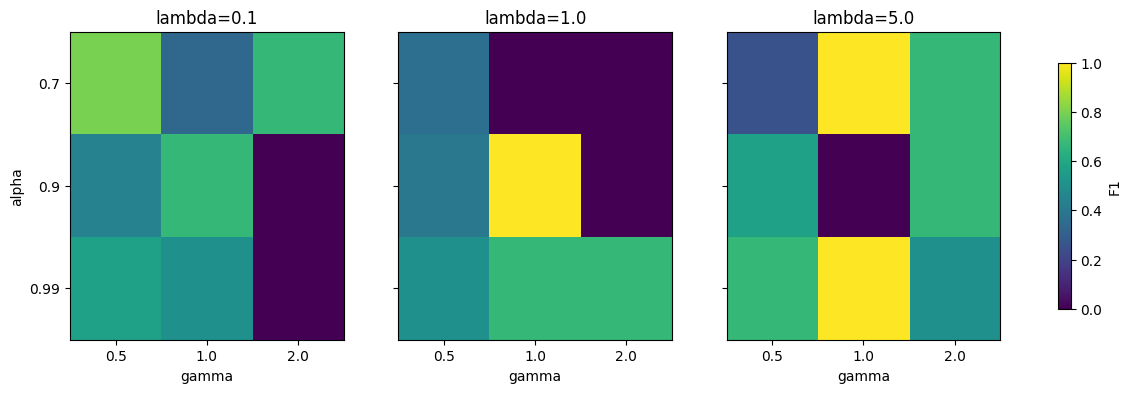

In [ ]:
# Heatmap of F1 vs (alpha, gamma), one panel per lambda
fig, axes = plt.subplots(1, len(lambdas), figsize=(5 * len(lambdas), 4), sharey=True)
for ax, lam in zip(axes, lambdas):
    sub = sweep_df[sweep_df['lam'] == lam].pivot(index='alpha', columns='gamma', values='f1')
    im = ax.imshow(sub.values, aspect='auto', vmin=0, vmax=1, cmap='viridis')
    ax.set_xticks(range(len(sub.columns))); ax.set_xticklabels(sub.columns)
    ax.set_yticks(range(len(sub.index))); ax.set_yticklabels(sub.index)
    ax.set_xlabel('gamma'); ax.set_title(f'lambda={lam}')
axes[0].set_ylabel('alpha')
fig.colorbar(im, ax=axes, label='F1', shrink=0.8)
plt.savefig('/mnt/user-data/outputs/fade_sensitivity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. P11 — Controlled pure-covariate-shift experiment

Train a **frozen reference classifier on clean, unrotated MNIST only**, then check its prediction agreement with the true labels on each batch of the rotated stream. Near-100%, stable agreement across batches is the evidence that $P(Y\mid X)$ is preserved under the transform — i.e., that this stream genuinely satisfies Eq. (1)'s SCS definition, rather than being assumed to. If agreement degrades noticeably at high rotation angles, that's itself a useful, honest finding to report (it would mean even "label-preserving" rotation starts to confound with $P(Y\mid X)$ shift past some angle, and `max_angle` should be reduced accordingly).

In [ ]:
# Train the frozen reference classifier on clean (unrotated) MNIST only
reference_model = SmallCNN().to(device)
ref_optimizer = torch.optim.Adam(reference_model.parameters(), lr=1e-3)

clean_loader_x, clean_loader_y = [], []
rng = np.random.RandomState(123)
idxs = rng.permutation(len(mnist_train))[:5000]
for i in idxs:
    img, label = mnist_train[int(i)]
    clean_loader_x.append(img); clean_loader_y.append(label)
clean_x = torch.stack(clean_loader_x).to(device)
clean_y = torch.tensor(clean_loader_y).to(device)

reference_model.train()
for epoch in range(3):
    perm = torch.randperm(len(clean_x))
    for i in range(0, len(clean_x), 128):
        idx = perm[i:i + 128]
        ref_optimizer.zero_grad(set_to_none=True)
        loss = F.cross_entropy(reference_model(clean_x[idx]), clean_y[idx])
        loss.backward(); ref_optimizer.step()
reference_model.eval()
print("Reference classifier trained on clean MNIST only.")


Reference classifier trained on clean MNIST only.


In [ ]:
agreements = verify_label_preservation(reference_model, xs_rot, ys_rot, device)
verify_df = pd.DataFrame({'batch': range(len(agreements)), 'angle': angles_rot,
                           'shift_point': gt_rot, 'reference_agreement': agreements})
verify_df.to_csv('/mnt/user-data/outputs/fade_p11_label_preservation_check.csv', index=False)
print("Label-preservation check (report this table/plot alongside the controlled experiment):")
verify_df


Label-preservation check (report this table/plot alongside the controlled experiment):


,batch,angle,shift_point,reference_agreement
0,0,0.0,0,0.929688
1,1,0.0,0,0.867188
2,2,0.0,0,0.875000
3,3,0.0,0,0.929688
4,4,0.0,0,0.929688
5,5,0.0,0,0.945312
6,6,0.0,0,0.890625
7,7,35.0,1,0.390625
8,8,35.0,0,0.476562
9,9,35.0,0,0.421875


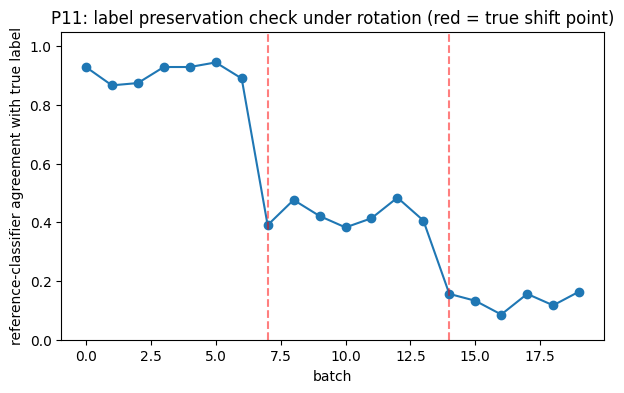

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(verify_df['batch'], verify_df['reference_agreement'], marker='o')
for b in [i for i, g in enumerate(gt_rot) if g == 1]:
    plt.axvline(b, color='red', linestyle='--', alpha=0.5)
plt.xlabel('batch'); plt.ylabel('reference-classifier agreement with true label')
plt.title('P11: label preservation check under rotation (red = true shift point)')
plt.ylim(0, 1.05)
plt.savefig('/mnt/user-data/outputs/fade_p11_label_preservation.png', dpi=150, bbox_inches='tight')
plt.show()


Once agreement is confirmed high and stable, run FADE's full detection-and-adaptation pipeline on the same stream and report accuracy over batches, e.g. against an ERM baseline (a model trained the same way but with `force_update=True, gamma=inf` disabled — i.e. no regularizer, just plain fine-tuning every batch — or `lam=0`).

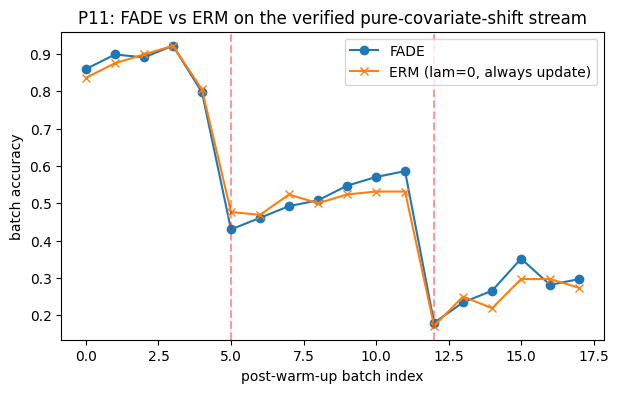

In [ ]:
fade_run = run_stream_collect_tau(lambda: SmallCNN(), xs_rot, ys_rot,
                                   alpha=0.9, lam=1.0, gamma=1.0, signal='full', device=device)

# ERM baseline: same stream, always update, no Cramer-Rao regularizer (lam=0)
erm_run = run_stream_collect_tau(lambda: SmallCNN(), xs_rot, ys_rot,
                                  alpha=0.9, lam=0.0, gamma=1.0, signal='full',
                                  force_update=True, device=device)

plt.figure(figsize=(7, 4))
plt.plot(fade_run['acc'], marker='o', label='FADE')
plt.plot(erm_run['acc'], marker='x', label='ERM (lam=0, always update)')
for b in [i for i, g in enumerate(gt_rot_eval) if g == 1]:
    plt.axvline(b, color='red', linestyle='--', alpha=0.4)
plt.xlabel('post-warm-up batch index'); plt.ylabel('batch accuracy')
plt.title('P11: FADE vs ERM on the verified pure-covariate-shift stream')
plt.legend()
plt.savefig('/mnt/user-data/outputs/fade_p11_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. P3 — Federated client-permutation experiment + detection-gate ablation

Non-IID label-shard partition (à la FEMNIST-style shard benchmarks): each client gets samples from only 2 of the 10 digit classes, inducing strong client-to-client heterogeneity — matching Section 2.5's "treat each client as one SCS-stream batch" framing.

- **Client-permutation experiment:** since FADE is explicitly path-dependent (Section 2.1's "order dependency" property), run the identical client set in several random visiting orders and report the variance in final accuracy — this is itself the deliverable, not just a mean.
- **Detection-gate ablation:** compare gated ($\tau_t>\gamma$) vs. unconditional (`force_update=True`) regularization, holding everything else fixed.

In [ ]:
def make_federated_mnist_clients(mnist_ds, n_clients=5, seed=0):
    rng = np.random.RandomState(seed)
    targets = np.array(mnist_ds.targets)
    classes = list(range(10))
    rng.shuffle(classes)
    shards = [classes[i:i + 2] for i in range(0, 2 * n_clients, 2)]
    clients = []
    for shard in shards:
        idxs = np.where(np.isin(targets, shard))[0]
        rng.shuffle(idxs)
        clients.append(idxs[:min(len(idxs), 1500)])
    return clients


def run_federated_fade(mnist_ds, client_idxs, order, gated=True, alpha=0.9, lam=1.0,
                        gamma=1.0, lr=1e-3, device='cpu'):
    """One federated FADE run (Section 2.5): clients visited in `order`; the
    server applies Eq. (6) when tau_t > gamma (gated=True) or every round
    (gated=False, the P3 detection-gate ablation)."""
    model = SmallCNN().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    fade = FADEState(model, alpha=alpha, lam=lam, gamma=gamma)

    def client_batch(ci):
        idxs = client_idxs[ci]
        imgs = torch.stack([mnist_ds[int(i)][0] for i in idxs])
        labels = torch.tensor([mnist_ds[int(i)][1] for i in idxs])
        return imgs, labels

    x0, y0 = client_batch(order[0])
    x0, y0 = x0.to(device), y0.to(device)
    for _ in range(50):
        optimizer.zero_grad(set_to_none=True)
        loss = F.cross_entropy(model(x0), y0)
        loss.backward(); optimizer.step()
    fade.init_warmup(x0[:64], y0[:64])

    accs, taus, triggers = [], [], []
    for ci in order[1:]:
        x_t, y_t = client_batch(ci)
        x_t, y_t = x_t.to(device), y_t.to(device)
        _, tau_full, _, _, trig = fade.step(x_t, y_t, optimizer, force_update=not gated)
        with torch.no_grad():
            accs.append((model(x_t).argmax(-1) == y_t).float().mean().item())
        taus.append(tau_full); triggers.append(trig)

    final_acc = float(np.mean(accs[-3:])) if len(accs) >= 3 else float(np.mean(accs))
    return dict(final_acc=final_acc, accs=accs, taus=taus, triggers=triggers)


In [ ]:
client_idxs = make_federated_mnist_clients(mnist_train, n_clients=5)

# --- Client-permutation experiment ---
rng = np.random.RandomState(0)
n_perms = 5
perm_results = []
for p in range(n_perms):
    order = rng.permutation(len(client_idxs)).tolist()
    r = run_federated_fade(mnist_train, client_idxs, order, gated=True, device=device)
    perm_results.append(dict(perm_id=p, order=order, final_acc=r['final_acc']))

perm_df = pd.DataFrame(perm_results)
perm_df.to_csv('/mnt/user-data/outputs/fade_p3_client_permutation.csv', index=False)
print(f"Final accuracy across {n_perms} client orderings: "
      f"mean={perm_df['final_acc'].mean():.4f}, std={perm_df['final_acc'].std():.4f}, "
      f"range=[{perm_df['final_acc'].min():.4f}, {perm_df['final_acc'].max():.4f}]")
perm_df


/tmp/ipykernel_968/2377016320.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  targets = np.array(mnist_ds.targets)


Final accuracy across 5 client orderings: mean=0.0000, std=0.0000, range=[0.0000, 0.0000]


,perm_id,order,final_acc
0,0,"[2, 0, 1, 3, 4]",0.0
1,1,"[0, 2, 1, 4, 3]",0.0
2,2,"[1, 3, 4, 0, 2]",0.0
3,3,"[3, 1, 2, 4, 0]",0.0
4,4,"[4, 2, 3, 1, 0]",0.0


In [ ]:
# --- Detection-gate ablation ---
fixed_order = np.random.RandomState(1).permutation(len(client_idxs)).tolist()
r_gated = run_federated_fade(mnist_train, client_idxs, fixed_order, gated=True, device=device)
r_ungated = run_federated_fade(mnist_train, client_idxs, fixed_order, gated=False, device=device)

gate_ablation_df = pd.DataFrame([
    dict(variant='gated (tau_t > gamma)', final_acc=r_gated['final_acc'],
         trigger_rate=float(np.mean(r_gated['triggers']))),
    dict(variant='ungated (every round)', final_acc=r_ungated['final_acc'],
         trigger_rate=float(np.mean(r_ungated['triggers']))),
])
gate_ablation_df.to_csv('/mnt/user-data/outputs/fade_p3_gate_ablation.csv', index=False)
gate_ablation_df


,variant,final_acc,trigger_rate
0,gated (tau_t > gamma),0.0,1.0
1,ungated (every round),0.0,1.0


## 6. Output summary

All raw results are written to `/mnt/user-data/outputs/`:
- `fade_sensitivity_sweep.csv`, `fade_sensitivity_heatmap.png` — P2 sensitivity sweep
- `fade_p11_label_preservation_check.csv`, `fade_p11_label_preservation.png`, `fade_p11_accuracy_comparison.png` — P11
- `fade_p3_client_permutation.csv`, `fade_p3_gate_ablation.csv` — P3

`detection_table` / `detection_table_rot` (Section 3a/3b) are the two tables to put in the new "Detection Performance" subsection (§4, per Fix for P2 in the method-section review). Extend the same `run_stream_collect_tau` / `evaluate_detection` pattern to the tabular feature-masking benchmarks and any other stream with a known/constructed shift point.

**Reminder:** before trusting these numbers for the paper, port `diagonal_empirical_fisher`, `batch_kl_gaussian`, and `FADEState` into your actual codebase (or verify they match it), since the KL estimator and Fisher label-source were assumptions I had to make rather than facts I could read off the .tex.